In [374]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [375]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [376]:
df = pd.read_csv(
    "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [377]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [378]:
df.shape

(7043, 21)

In [379]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [381]:
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [382]:
df["TotalCharges"].nunique()

6531

In [383]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [384]:
df[df["TotalCharges"] == " "][["tenure", "TotalCharges", "Churn"]]

,tenure,TotalCharges,Churn
488,0,,No
753,0,,No
936,0,,No
1082,0,,No
1340,0,,No
3331,0,,No
3826,0,,No
4380,0,,No
5218,0,,No
6670,0,,No


In [385]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [386]:
df["TotalCharges"].dtype

dtype('float64')

In [387]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [388]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [389]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [390]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [391]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn'>

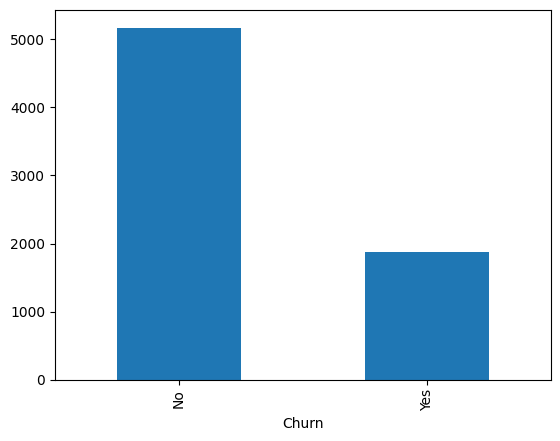

In [392]:
df["Churn"].value_counts().plot(kind="bar")

In [393]:
df.groupby("Churn")["tenure"].mean()


Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [394]:
print(df.groupby("Churn")["tenure"].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [395]:
print(pd.crosstab(df["Contract"], df["Churn"]))

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [396]:
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [397]:
print(pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [398]:
print(df.groupby("Churn")["MonthlyCharges"].mean())


Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [399]:
print(pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [400]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: xlabel='Contract'>

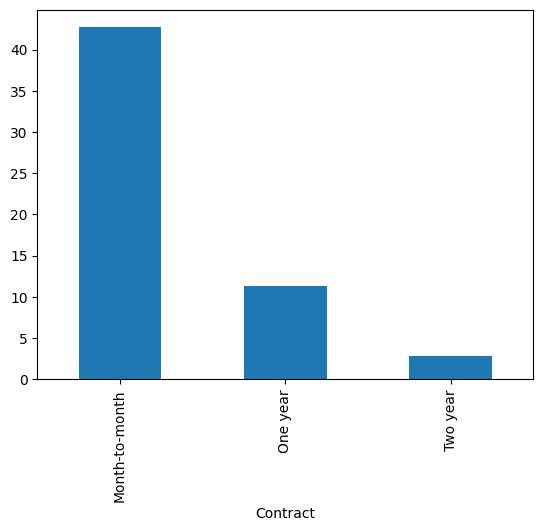

In [401]:
contract_churn["Yes"].plot(kind="bar")

In [402]:
import matplotlib.pyplot as plt

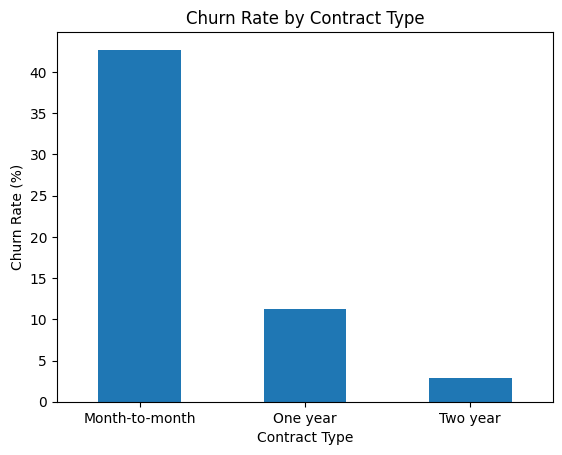

In [403]:
contract_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Contract Type"
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

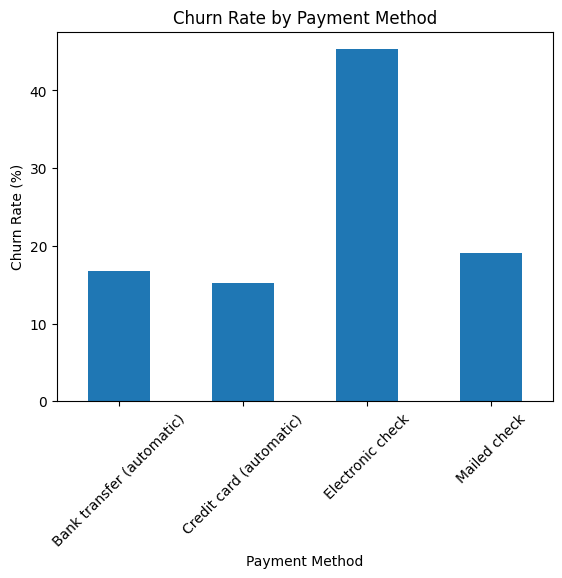

In [404]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

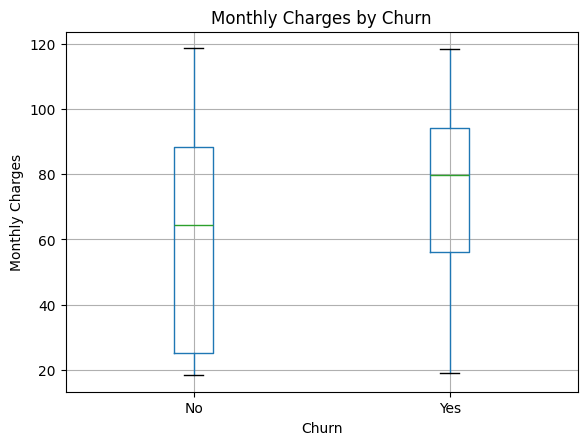

In [405]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

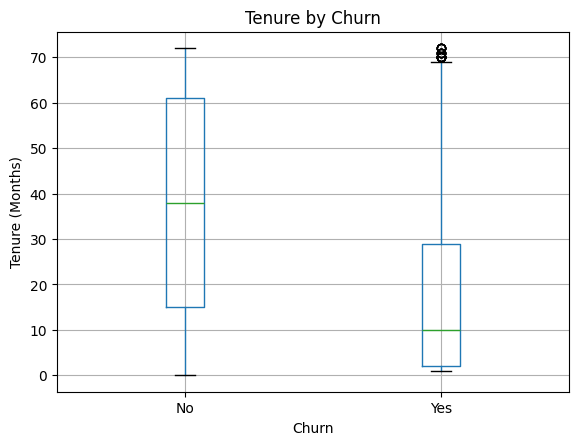

In [406]:
df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

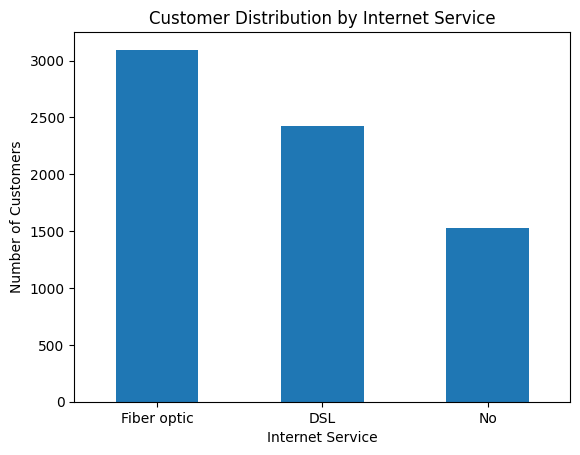

In [407]:
df["InternetService"].value_counts().plot(
    kind="bar",
    title="Customer Distribution by Internet Service"
)

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [408]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


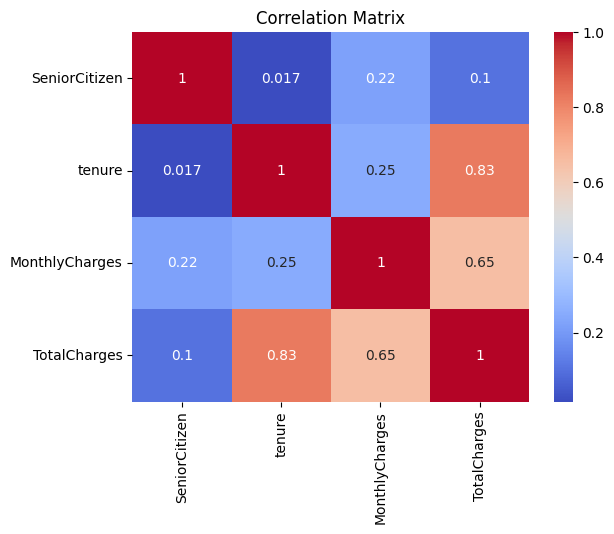

In [409]:
import seaborn as sns

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## EDA Summary

The exploratory data analysis revealed several important patterns related to customer churn:

- Customers who churned had a lower average tenure than customers who stayed.
- Month-to-month contract customers had a much higher churn rate (42.71%) compared with one-year (11.27%) and two-year contracts (2.83%).
- Customers using electronic check had the highest churn rate (45.29%) among the payment methods.
- Churned customers had higher average monthly charges (74.44) compared with customers who stayed (61.27).
- Fiber optic customers had a higher churn rate (41.89%) compared with DSL customers (18.96%).
- The correlation analysis showed a strong positive relationship between tenure and TotalCharges (0.826).

These findings provide useful insights for the next stage of the project, where the data will be prepared for machine learning and churn prediction.

In [410]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [411]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [412]:
df["Churn"].value_counts(dropna=False)

Churn
0    5174
1    1869
Name: count, dtype: int64

In [413]:
df = df.drop("customerID", axis=1)

In [414]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [415]:
categorical_cols = df.select_dtypes(include="object").columns

print(categorical_cols)
print("Number of categorical columns:", len(categorical_cols))

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Number of categorical columns: 15


In [416]:
for col in categorical_cols:
    print(col, ":", df[col].nunique())

gender : 2
Partner : 2
Dependents : 2
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4


In [417]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [418]:
print(df_encoded.shape)

(7043, 31)


In [419]:
df_encoded.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [420]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [421]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [422]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [423]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [424]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [425]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (5634, 30)
X_test_scaled shape: (1409, 30)


In [426]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [427]:
y_pred = logistic_model.predict(X_test_scaled)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [428]:
print(y_test[:20])

437     0
2280    0
2235    0
4460    0
3761    0
5748    0
3568    0
2976    0
5928    0
1639    1
2079    0
1280    0
667     0
3524    1
5283    0
485     0
6121    0
2136    0
6501    0
5356    0
Name: Churn, dtype: int64


In [429]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8069552874378992


In [430]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [162 212]]


In [431]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [432]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [433]:
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree[:20])

[0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]


In [434]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.7260468417317246


In [435]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1035
           1       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [436]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [437]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [438]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7849538679914834


In [439]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))



              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [440]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [441]:
y_pred_knn = knn_model.predict(X_test_scaled)

print(y_pred_knn[:20])

[0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [442]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7473385379701917


In [443]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1035
           1       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



## Model Comparison

Four classification models were trained and evaluated using the same train-test split:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)

Logistic Regression achieved the highest accuracy and the best performance for the churn class among the tested models.

| Model | Accuracy | Churn Precision | Churn Recall | Churn F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.70% | 0.66 | 0.57 | 0.61 |
| Random Forest | 78.50% | 0.62 | 0.50 | 0.55 |
| KNN | 74.73% | 0.53 | 0.50 | 0.51 |
| Decision Tree | 72.60% | 0.48 | 0.48 | 0.48 |

### Initial Conclusion

Logistic Regression currently performs best among the four tested models. It achieved the highest accuracy (80.70%) and the highest recall (57%) for customers who churned.

However, these results are based on a single train-test split. Cross-validation will be used next to check whether the model performance is consistent across different subsets of the training data.

In [444]:
from sklearn.model_selection import cross_val_score

cv_scores_logistic = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:", cv_scores_logistic)
print("Mean CV Accuracy:", cv_scores_logistic.mean())

Logistic Regression CV Scores: [0.82786158 0.80124224 0.80745342 0.79414374 0.79129663]
Mean CV Accuracy: 0.8043995202529232


In [445]:
cv_scores_tree = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree CV Scores:", cv_scores_tree)
print("Mean CV Accuracy:", cv_scores_tree.mean())

Decision Tree CV Scores: [0.7284827  0.73114463 0.72227152 0.71960958 0.73179396]
Mean CV Accuracy: 0.7266604780764727


In [446]:
cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", cv_scores_rf)
print("Mean CV Accuracy:", cv_scores_rf.mean())

Random Forest CV Scores: [0.80390417 0.79769299 0.78881988 0.77196096 0.77975133]
Mean CV Accuracy: 0.7884258653650665


In [447]:
cv_scores_knn = cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("KNN CV Scores:", cv_scores_knn)
print("Mean CV Accuracy:", cv_scores_knn.mean())

KNN CV Scores: [0.77994676 0.76042591 0.76486247 0.76220053 0.74511545]
Mean CV Accuracy: 0.762510224570174


## Cross-Validation Results

To check whether the model performance was consistent across different subsets of the training data, 5-fold cross-validation was performed for all four models.

| Model | Mean CV Accuracy |
|---|---:|
| Logistic Regression | 80.44% |
| Random Forest | 78.84% |
| KNN | 76.25% |
| Decision Tree | 72.67% |

### Conclusion

Logistic Regression achieved the highest mean cross-validation accuracy (80.44%), followed by Random Forest (78.84%), KNN (76.25%), and Decision Tree (72.67%).

The Logistic Regression model also achieved a similar accuracy on the original test set (80.70%). The close results between the test-set accuracy and cross-validation accuracy suggest that the model's performance is relatively stable across different training and validation splits.

Based on the current evaluation, Logistic Regression is the strongest baseline model among the four tested models.

>>>>>>>>>>>>            

## Hyperparameter Tuning

The Logistic Regression model achieved the best baseline performance. The next step is to tune its hyperparameters to determine whether its performance can be improved.

The `C` parameter controls the strength of regularization. Different values of `C` will be evaluated using 5-fold cross-validation.

In [448]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_scaled, y_train)

print("Best C:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best C: {'C': 100}
Best CV Accuracy: 0.8051093694099773


In [449]:
best_logistic_model = grid_search.best_estimator_

y_pred_tuned = best_logistic_model.predict(X_test_scaled)

print("Tuned Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

Tuned Logistic Regression Accuracy: 0.801277501774308


## Final Model Evaluation

Logistic Regression achieved the best overall performance among the tested models. The confusion matrix will be used to examine how well the model identifies customers who churn and customers who stay.

In [450]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [162 212]]


### Confusion Matrix Interpretation

The confusion matrix shows how the Logistic Regression model classified customers:

- **True Negatives (925):** Customers who stayed and were correctly predicted to stay.
- **False Positives (110):** Customers who stayed but were incorrectly predicted to churn.
- **False Negatives (162):** Customers who churned but were incorrectly predicted to stay.
- **True Positives (212):** Customers who churned and were correctly identified by the model.

There were 374 actual churn customers in the test set, and the model correctly identified 212 of them.

Therefore, the model achieved approximately 57% recall for the churn class. This means the model detected around 57% of customers who actually churned, while missing around 43%.

For a customer retention use case, reducing false negatives is important because these represent customers who may churn but were not identified by the model.

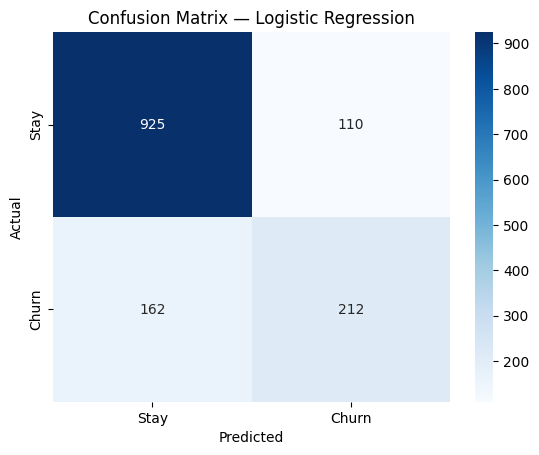

In [451]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

In [452]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.841778397788628


## ROC-AUC Evaluation

The ROC-AUC score was used to evaluate how well the Logistic Regression model can distinguish between customers who churn and customers who stay across different classification thresholds.

The model achieved a ROC-AUC score of **0.842**.

This indicates that the model has good ability to distinguish between churn and non-churn customers. However, the model still misses a significant number of actual churn customers at the default classification threshold, as shown by the churn recall of approximately 57%.

Therefore, while the model provides a strong baseline, further improvement could focus on increasing churn recall while maintaining a reasonable level of precision.

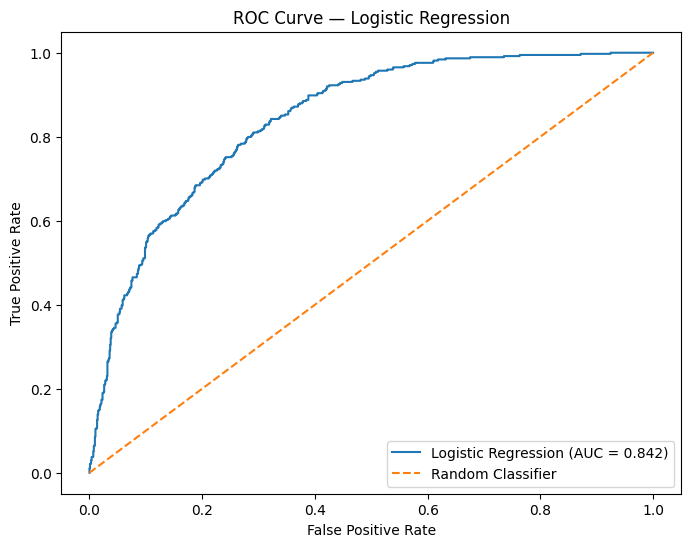

In [453]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()


In [454]:
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.4

y_pred_threshold = (y_prob >= threshold).astype(int)

print("Predictions with threshold 0.4:")
print(y_pred_threshold[:20])

Predictions with threshold 0.4:
[0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [455]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_threshold
))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



## Threshold Tuning

By default, Logistic Regression uses a classification threshold of 0.5. The threshold was reduced to 0.4 to investigate its effect on churn detection.

| Metric | Threshold 0.5 | Threshold 0.4 |
|---|---:|---:|
| Accuracy | 80.70% | 78.00% |
| Churn Precision | 0.66 | 0.57 |
| Churn Recall | 0.57 | 0.67 |
| Churn F1 | 0.61 | 0.61 |

Lowering the threshold from 0.5 to 0.4 increased churn recall from 57% to 67%. This means the model identified more customers who were actually going to churn.

However, churn precision decreased from 66% to 57%, and overall accuracy decreased from 80.70% to 78.00%.

This demonstrates the precision-recall trade-off. In a customer retention scenario, a lower threshold may be useful when identifying potential churners is more important than minimizing false positive predictions.

In [456]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds_to_test:
    y_pred_temp = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_temp)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.2 | Precision: 0.47 | Recall: 0.86 | F1: 0.60
Threshold: 0.3 | Precision: 0.52 | Recall: 0.75 | F1: 0.62
Threshold: 0.4 | Precision: 0.57 | Recall: 0.67 | F1: 0.61
Threshold: 0.5 | Precision: 0.66 | Recall: 0.57 | F1: 0.61
Threshold: 0.6 | Precision: 0.71 | Recall: 0.40 | F1: 0.51
Threshold: 0.7 | Precision: 0.73 | Recall: 0.17 | F1: 0.28


## Threshold Comparison

Several classification thresholds were evaluated to understand the trade-off between precision and recall.

| Threshold | Precision | Recall | F1 |
|---:|---:|---:|---:|
| 0.2 | 0.47 | 0.86 | 0.60 |
| 0.3 | 0.52 | 0.75 | 0.62 |
| 0.4 | 0.57 | 0.67 | 0.61 |
| 0.5 | 0.66 | 0.57 | 0.61 |
| 0.6 | 0.71 | 0.40 | 0.51 |
| 0.7 | 0.73 | 0.17 | 0.28 |

The results demonstrate a clear precision-recall trade-off. Lowering the threshold increases recall but decreases precision, while increasing the threshold has the opposite effect.

Among the tested thresholds, 0.3 achieved the highest F1-score of 0.62 while maintaining a churn recall of 75%.

For the current customer retention use case, a threshold of 0.3 is a reasonable candidate because identifying potential churners is important. However, the final threshold should ideally be selected based on the actual business cost of false positives and false negatives.

In [457]:
threshold = 0.3

y_pred_03 = (y_prob >= threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_03))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_03))

Confusion Matrix:
[[774 261]
 [ 92 282]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



## Final Threshold Comparison

The default threshold of 0.5 was compared with a lower threshold of 0.3.

| Metric | Threshold 0.5 | Threshold 0.3 |
|---|---:|---:|
| Accuracy | 80.70% | 75.00% |
| Churn Precision | 0.66 | 0.52 |
| Churn Recall | 0.57 | 0.75 |
| Churn F1 | 0.61 | 0.62 |
| Churn Customers Detected | 212 / 374 | 282 / 374 |
| Churn Customers Missed | 162 | 92 |

Lowering the threshold from 0.5 to 0.3 increased churn recall from 57% to 75%. The model identified 282 of the 374 actual churn customers, compared with 212 at the default threshold.

However, this improvement came at the cost of lower precision and lower overall accuracy. False positives increased from 110 to 261.

This demonstrates the practical precision-recall trade-off in classification. For a customer retention use case, the 0.3 threshold is a reasonable candidate because identifying potential churners is more important than maximizing overall accuracy.

The threshold should ultimately be selected based on the business cost of false positives and false negatives.

In [458]:
from sklearn.linear_model import LogisticRegression

balanced_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [459]:
y_pred_balanced = balanced_logistic_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Handling Class Imbalance

The Logistic Regression model was retrained using `class_weight="balanced"` to give more importance to the minority churn class.

Compared with the baseline model, the balanced model increased churn recall from 57% to 79%. However, this resulted in lower precision and lower overall accuracy.

| Metric | Baseline | Balanced |
|---|---:|---:|
| Accuracy | 80.70% | 74% |
| Churn Precision | 0.66 | 0.51 |
| Churn Recall | 0.57 | 0.79 |
| Churn F1 | 0.61 | 0.62 |

The balanced model is much better at identifying potential churners, but it also produces more false positive predictions.

This shows that handling class imbalance can improve minority-class recall while reducing overall accuracy and precision.

In [460]:
y_prob_balanced = balanced_logistic_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_balanced = roc_auc_score(
    y_test,
    y_prob_balanced
)

print("Balanced Logistic Regression ROC-AUC:", roc_auc_balanced)

Balanced Logistic Regression ROC-AUC: 0.8414012245214291


In [461]:
final_threshold = 0.3

final_model = logistic_model

final_probabilities = final_model.predict_proba(X_test_scaled)[:, 1]

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)

print("Final threshold:", final_threshold)
print("Final predictions:", final_predictions[:20])

Final threshold: 0.3
Final predictions: [0 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0]


## Final Model Selection

After comparing multiple classification models, evaluating cross-validation performance, tuning hyperparameters, handling class imbalance, and testing different classification thresholds, Logistic Regression was selected as the final model.

The final configuration uses the original Logistic Regression model with a classification threshold of 0.3.

### Final Model

- **Algorithm:** Logistic Regression
- **Classification Threshold:** 0.3
- **Test Accuracy:** 75.00%
- **Churn Precision:** 0.52
- **Churn Recall:** 0.75
- **Churn F1-score:** 0.62
- **ROC-AUC:** 0.842

The default threshold of 0.5 achieved higher overall accuracy (80.70%), but it detected only 57% of actual churn customers. Lowering the threshold to 0.3 increased churn recall to 75%, reducing the number of missed churn customers from 162 to 92.

Therefore, threshold 0.3 was selected as the current operating threshold because customer retention is the main business objective and identifying potential churners is important.

This threshold is a practical project choice rather than a universally optimal threshold. In a real-world deployment, the threshold should be optimized using actual business costs associated with false positives and false negatives.

>>>>>>>>>>>

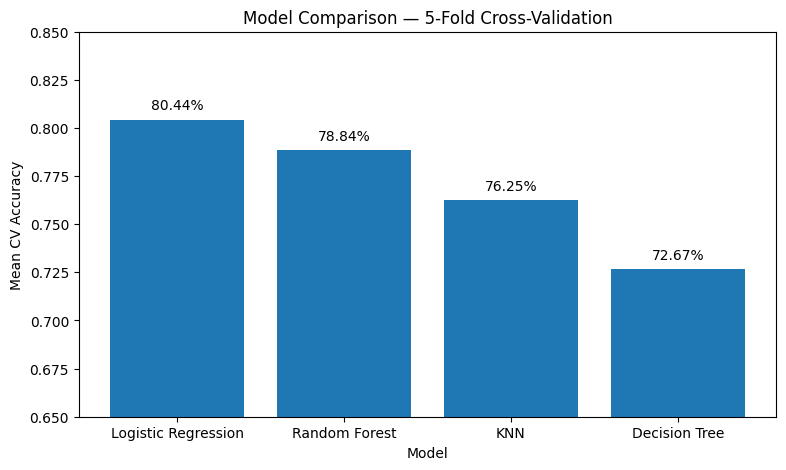

In [462]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN",
        "Decision Tree"
    ],
    "CV Accuracy": [
        0.8044,
        0.7884,
        0.7625,
        0.7267
    ]
})

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["CV Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy")
plt.title("Model Comparison — 5-Fold Cross-Validation")

plt.ylim(0.65, 0.85)

for i, value in enumerate(model_comparison["CV Accuracy"]):
    plt.text(
        i,
        value + 0.005,
        f"{value:.2%}",
        ha="center"
    )

plt.show()

## Final Conclusion

This project used the Telco Customer Churn dataset to explore customer behavior and build a machine learning model for churn prediction.

### Key Findings from EDA

The exploratory analysis revealed several important patterns:

- Customers with shorter tenure were more likely to churn.
- Month-to-month contract customers had a substantially higher churn rate than customers with one-year or two-year contracts.
- Electronic check users had the highest churn rate among payment methods.
- Customers who churned had higher average monthly charges.
- Fiber optic customers showed a higher churn rate compared with DSL customers.
- Tenure and TotalCharges had a strong positive correlation.

### Machine Learning Findings

Four classification algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)

Logistic Regression achieved the strongest baseline performance, with a mean 5-fold cross-validation accuracy of 80.44%.

Hyperparameter tuning was also performed using GridSearchCV. The best value was `C=100`, but the improvement in cross-validation accuracy was very small and the tuned model did not improve the final test accuracy. Therefore, the baseline Logistic Regression model was retained.

### Final Model

The final model uses Logistic Regression with a classification threshold of 0.3.

The threshold was reduced from the default 0.5 because identifying customers who are likely to churn is particularly important for a customer retention use case.

The final model achieved:

- Test Accuracy: 75.00%
- Churn Precision: 52%
- Churn Recall: 75%
- Churn F1-score: 0.62
- ROC-AUC: 0.842

At the 0.3 threshold, the model correctly identified 282 of the 374 actual churn customers, while missing 92.

### Limitations

This project has several limitations:

- The dataset represents a specific telecom customer population and may not generalize to other businesses.
- The model was evaluated using a single train-test split for the final test evaluation.
- The threshold was selected using a small set of candidate values rather than a formal business cost function.
- The project focuses on predictive performance and does not include actual customer retention campaign outcomes.

### Possible Future Improvements

Future work could include:

- More advanced hyperparameter tuning.
- Feature engineering based on customer behavior.
- Testing gradient boosting models such as XGBoost or LightGBM.
- Using precision-recall curves to select an operating threshold.
- Optimizing the threshold based on actual business costs.
- Model explainability using techniques such as SHAP.
- Building a deployment pipeline that predicts churn for new customers.

Overall, this project demonstrates an end-to-end machine learning workflow from data cleaning and exploratory analysis to model training, evaluation, cross-validation, hyperparameter tuning, class imbalance handling, and threshold optimization.